# Code for polished versions of Fig 5 - pangenome integration

## Main panel figures 

In [1]:
### Read in Faith's haploid data results to a df 

import pandas as pd

df = pd.read_csv(
    '/private/home/fokamoto/centromere-haplotype-sampling-pipeline/plot_outputs/haploid_data.tsv',
    sep='\t'
)
#for col in df.columns:
    #print(col)


In [3]:
for col in df.columns:
    print(col)

Chromosome
Haplotype name
Truth cenhap
Guessed cenhap
Sampled haplotype names
Sampled haplotype scores
Sampled haplotype depths
Minimum graph distance
Minimum sampled distance
CHM13 minimap2 real identity
CHM13 minimap2 real correctness
CHM13 minimap2 real runtime
CHM13 minimap2 real memory
CHM13 giraffe real identity
CHM13 giraffe real correctness
CHM13 giraffe real runtime
CHM13 giraffe real memory
CHM13 minimap2 sim identity
CHM13 minimap2 sim correctness
CHM13 minimap2 sim runtime
CHM13 minimap2 sim memory
CHM13 giraffe sim identity
CHM13 giraffe sim correctness
CHM13 giraffe sim runtime
CHM13 giraffe sim memory
Neighbor minimap2 real identity
Neighbor minimap2 real correctness
Neighbor minimap2 real runtime
Neighbor minimap2 real memory
Neighbor giraffe real identity
Neighbor giraffe real correctness
Neighbor giraffe real runtime
Neighbor giraffe real memory
Neighbor minimap2 sim identity
Neighbor minimap2 sim correctness
Neighbor minimap2 sim runtime
Neighbor minimap2 sim memory


#### Whole genome, Haploid CenHap typing 

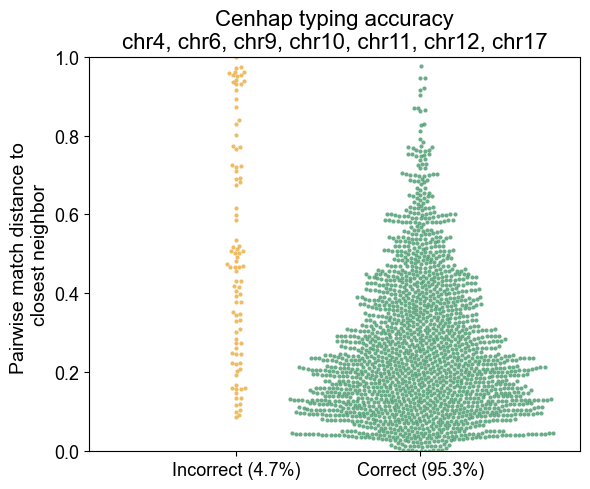

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

def swarmplot(xPos, yList, panel, color, pointSize, span, xRange, pW, yRange, pH):
    placedPoints = []
    minDist = (pointSize / 72) * 1.2
    increment = minDist / 20

    xList = []
    for shift in np.arange(0, span / 2, increment):
        xList.append(xPos + shift)
        xList.append(xPos - shift)

    for y1 in sorted(yList):
        placed = False
        if not placedPoints:
            placedPoints.append((xPos, y1))
            placed = True
        else:
            comparePoints = [
                (x2, y2) for x2, y2 in placedPoints
                if abs((y1 - y2) / yRange * pH) <= minDist
            ]
            if not comparePoints:
                placedPoints.append((xPos, y1))
                placed = True
            else:
                for x1 in xList:
                    if not placed:
                        dists = [
                            np.sqrt(((x1 - x2) / xRange * pW) ** 2 +
                                    ((y1 - y2) / yRange * pH) ** 2)
                            for x2, y2 in comparePoints
                        ]
                        if min(dists) > minDist:
                            placedPoints.append((x1, y1))
                            placed = True
        if not placed:
            placedPoints.append((xPos, y1))

    for x, y in placedPoints:
        x_noise = x + np.random.uniform(-increment / 2, increment / 2)
        panel.plot(x_noise, y, marker='o', ms=pointSize, mew=0, mfc=color, alpha=0.7, lw=0)

# ── data prep ─────────────────────────────────────────────────────────────────

filt_df = df.copy()
filt_df["Correctness"] = (filt_df["Truth cenhap"] == filt_df["Guessed cenhap"]).map({True: "Correct", False: "Incorrect"})

incorrect_vals = filt_df[filt_df["Correctness"] == "Incorrect"]["Minimum graph distance"].dropna().values
correct_vals   = filt_df[filt_df["Correctness"] == "Correct"]["Minimum graph distance"].dropna().values

n_total       = len(incorrect_vals) + len(correct_vals)
pct_incorrect = 100 * len(incorrect_vals) / n_total
pct_correct   = 100 * len(correct_vals)   / n_total

chroms = ', '.join(sorted(filt_df['Chromosome'].unique(),
                          key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 99))

# ── figure ────────────────────────────────────────────────────────────────────

pW, pH = 6, 5
fig, ax = plt.subplots(figsize=(pW, pH))

xmin, xmax, ymin, ymax = -1.5, 2.5, 0, 1
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

swarmplot(-0.3, incorrect_vals, ax, '#E6A024',   3, 2.2, xmax - xmin, pW, ymax - ymin, pH)
swarmplot(1.2, correct_vals,   ax, 'seagreen', 3, 2.2, xmax - xmin, pW, ymax - ymin, pH)

ax.set_xticks([-0.3, 1.2])
ax.set_xticklabels([f'Incorrect ({pct_incorrect:.1f}%)', f'Correct ({pct_correct:.1f}%)'], fontsize=13)
ax.set_ylabel("Pairwise match distance to \nclosest neighbor", fontsize=14)
ax.set_xlabel("")
ax.set_title(f"Cenhap typing accuracy\n{chroms}", fontsize=16)
ax.tick_params(axis='y', labelsize=13)

fig.tight_layout()
plt.show()



### Haploid read alignment performance, whole genome 

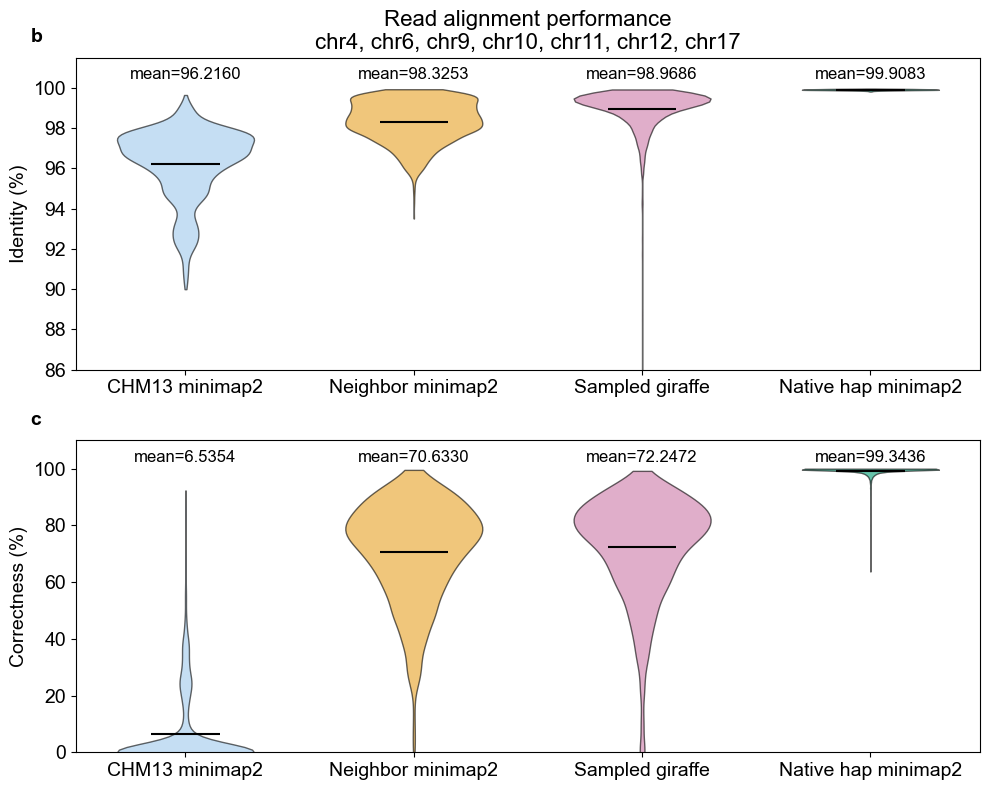

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Arial'

def filter_columns(header, col_type, real):
    cols = []
    for h in header:
        if col_type not in h:
            continue
        if real and 'sim' in h:
            continue
        if not real and 'real' in h:
            continue
        if 'minimap2' in h or 'Sampled giraffe' in h:
            cols.append(h)
    return cols

def violin_panel(ax, filt_df, cols, colors, ylabel, pW, pH, scale=1.0):
    for i, col in enumerate(cols):
        vals = pd.to_numeric(filt_df[col], errors='coerce').dropna().values * scale
        parts = ax.violinplot([vals], positions=[i], widths=0.6,
                              showmeans=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.6)
        parts['cmeans'].set_color('black')
        parts['cmeans'].set_linewidth(1.5)

        tmp = pd.DataFrame({'val': vals, '_pos': i})
        #sns.swarmplot(data=tmp, x='_pos', y='val', ax=ax,
        #              color=colors[i], size=2, alpha=0.6,
        #              native_scale=True)

        mean_val = np.mean(vals)
        ymin, ymax = ax.get_ylim()
        label_y = ymax - (ymax - ymin) * 0.03
        ax.annotate(f'mean={mean_val:.4f}', xy=(i, label_y),
                    ha='center', va='top', fontsize=12)

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([' '.join(c.split()[:-2]) for c in cols], fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

# ── data prep ─────────────────────────────────────────────────────────────────

header  = df.columns.tolist()
filt_df = df.copy()

id_cols  = filter_columns(header, 'identity',    real=True)
cor_cols = filter_columns(header, 'correctness', real=True)

color_map = {
    'CHM13 minimap2':      '#9FC9EB',
    'Neighbor minimap2':   '#E6A024',
    'Native hap minimap2': '#009E73',
    'Sampled giraffe':     '#CC79A7',
}
colors = [color_map.get(' '.join(c.split()[:-2]), '#aaaaaa') for c in id_cols]

chroms = ', '.join(sorted(filt_df['Chromosome'].unique(),
                          key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 99))

# ── figure ────────────────────────────────────────────────────────────────────

pW, pH = 10, 4
fig, (ax_b, ax_c) = plt.subplots(2, 1, figsize=(pW, pH * 2))
ax_b.set_ylim(86, 101.5)
ax_c.set_ylim(0, 110)
ax_b.set_title("")
ax_c.set_title("")
violin_panel(ax_b, filt_df, id_cols,  colors, "Identity (%)",    pW, pH, scale=100)
violin_panel(ax_c, filt_df, cor_cols, colors, "Correctness (%)", pW, pH,scale=1)

from matplotlib.ticker import FormatStrFormatter
ax_b.yaxis.set_major_formatter(FormatStrFormatter('%d'))

ax_b.set_title(f"Read alignment performance\n{chroms}", fontsize=16)

for ax, letter in zip([ax_b, ax_c], "bc"):
    ax.text(-0.05, 1.05, letter, transform=ax.transAxes, fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()


## Supplementary figures

### P1. Min sampled dist vs min graph dist

/data/tmp/ipykernel_1466682/589303471.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


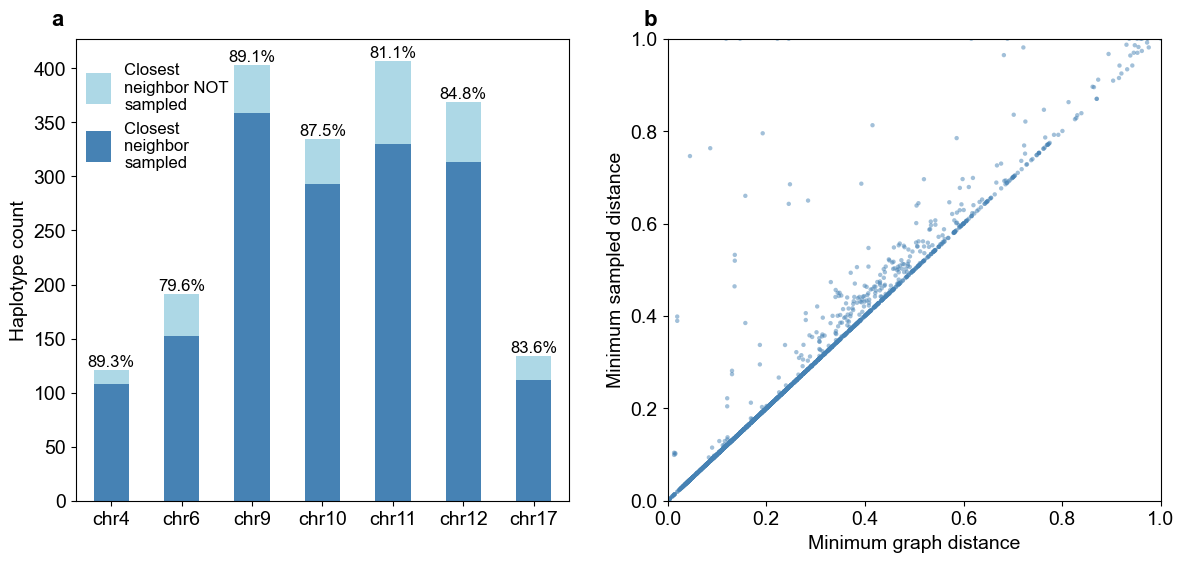

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Arial'

df['distance_diff'] = df['Minimum graph distance'] - df['Minimum sampled distance']
df['diff_category'] = df['distance_diff'].abs().apply(lambda x: 'zero' if x == 0 else 'greater than zero')

# Count per chromosome and category
counts = df.groupby(['Chromosome', 'diff_category']).size().unstack(fill_value=0)
for col in ['zero', 'greater than zero']:
    if col not in counts.columns:
        counts[col] = 0

chrom_order = sorted(counts.index, key=lambda x: (
    int(x.replace('chr','')) if x.replace('chr','').isdigit() else float('inf'), x
))
counts = counts.loc[chrom_order]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'wspace': 0.2})

# --- Left: stacked bar ---
counts['zero'].plot(kind='bar', ax=ax1, color='steelblue')
counts['greater than zero'].plot(kind='bar', ax=ax1, bottom=counts['zero'], color='lightblue')
ax1.set_ylabel('Haplotype count', fontsize=14)
ax1.set_xlabel("")
ax1.tick_params(labelsize=14)
ax1.set_xticklabels(counts.index, rotation=0, ha='center', fontsize=14)

# Percent labels on top of each bar
total = counts['zero'] + counts['greater than zero']
pct = (counts['zero'] / total * 100).round(1)
for i, (val, tot, p) in enumerate(zip(counts['zero'], total, pct)):
    ax1.text(i, tot + 0.5, f'{p}%', ha='center', va='bottom', fontsize=12, color='black')

legend_elements = [Patch(facecolor='steelblue', label='Closest \nneighbor \nsampled'),
                   Patch(facecolor='lightblue', label='Closest \nneighbor NOT \nsampled')]
legend = ax1.legend(handles=legend_elements[::-1], fontsize=12, loc='upper left',
                    frameon=False, bbox_to_anchor=(-0.01, 0.98),
                    handlelength=1.5, handleheight=2.5)

# --- Right: scatter ---
ax2.scatter(df['Minimum graph distance'], df['Minimum sampled distance'],
            s=10, alpha=0.5, color='steelblue', edgecolors='none')
ax2.set_xlabel("Minimum graph distance", fontsize=14)
ax2.set_ylabel("Minimum sampled distance", fontsize=14)
ax2.tick_params(labelsize=14)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

# Panel labels
for ax, label in zip([ax1, ax2], ['a', 'b']):
    ax.text(-0.05, 1.02, label, transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='bottom', ha='left', fontfamily='Arial')

plt.tight_layout()
plt.savefig('/private/groups/patenlab/mira/Sec5_Sup_P1.png', dpi=600, bbox_inches='tight')
plt.savefig('/private/groups/patenlab/mira/Sec5_Sup_P1.svg', bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df['distance_diff'] = df['Minimum graph distance'] - df['Minimum sampled distance']

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['distance_diff'], bins=50, edgecolor='black', linewidth=0.5)

ax.axvline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Min graph distance - Min sampled distance')
ax.set_ylabel('Count')
ax.set_title('Distribution of distance differences')

plt.tight_layout()
#plt.savefig('distance_diff_histogram.png', dpi=150)
plt.show()

### P3. Diploid cenhap typing swarm plots 

In [46]:
### Read in Faith's haploid data results to a df 

import pandas as pd

dip_df = pd.read_csv(
    '/private/home/fokamoto/centromere-haplotype-sampling-pipeline/plot_outputs/diploid_data.tsv',
    sep='\t'
)
for col in dip_df.columns:
    print(col)

Chromosome
Sample
Truth cenhaps
Guessed cenhaps


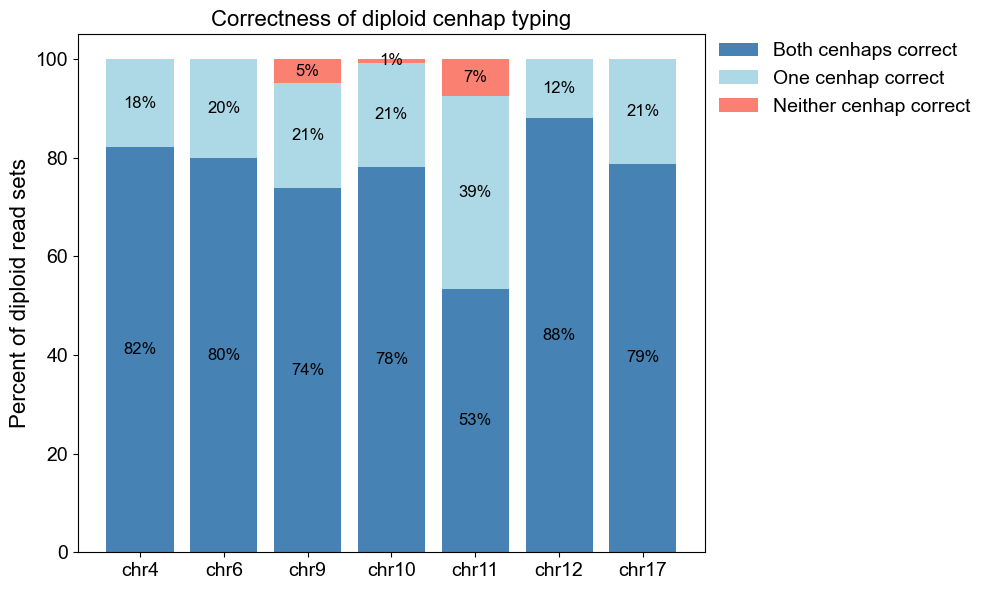

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams['font.family'] = 'Arial'

from collections import Counter

def normalize_cenhaps(val):
    return ','.join([f'cenhap{x.strip()}' for x in str(val).split(',')])

dip_df['Truth cenhaps norm'] = dip_df['Truth cenhaps'].apply(normalize_cenhaps)
dip_df['Guessed cenhaps norm'] = dip_df['Guessed cenhaps'].apply(normalize_cenhaps)

def score_guess(row):
    truth = Counter(row['Truth cenhaps norm'].split(','))
    guessed = Counter(row['Guessed cenhaps norm'].split(','))
    correct = sum((truth & guessed).values())
    if correct == 2:
        return 'Both correct'
    elif correct == 1:
        return 'One correct'
    else:
        return 'None correct'

dip_df['category'] = dip_df.apply(score_guess, axis=1)

counts = dip_df.groupby(['Chromosome', 'category']).size().unstack(fill_value=0)
for col in ['Both correct', 'One correct', 'None correct']:
    if col not in counts.columns:
        counts[col] = 0
counts = counts[['Both correct', 'One correct', 'None correct']]

chrom_order = sorted(counts.index, key=lambda x: (
    int(x.replace('chr','')) if x.replace('chr','').isdigit() else float('inf'), x
))
counts = counts.loc[chrom_order]

pct = counts.div(counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['steelblue', 'lightblue', 'salmon']
bottoms = pd.Series([0.0] * len(pct), index=pct.index)
for col, color in zip(['Both correct', 'One correct', 'None correct'], colors):
    ax.bar(range(len(pct)), pct[col], bottom=bottoms, color=color, label=col)
    # Add percentage labels inside each stack
    for i, (val, bot) in enumerate(zip(pct[col], bottoms)):
        if val > 0:
            ax.text(i, bot + val / 2, f'{val:.0f}%',
                    ha='center', va='center', fontsize=12, color='black')
    bottoms += pct[col]

ax.set_xticks(range(len(pct)))
ax.set_xticklabels(pct.index, rotation=0, ha='center', fontsize=18)
ax.set_ylabel('Percent of diploid read sets', fontsize=16)
ax.set_xlabel('')
ax.set_ylim(0, 105)
ax.set_title("Correctness of diploid cenhap typing",fontsize=16)
ax.tick_params(labelsize=14)

legend_elements = [Patch(facecolor='steelblue', label='Both cenhaps correct'),
                   Patch(facecolor='lightblue', label='One cenhap correct'),
                   Patch(facecolor='salmon', label='Neither cenhap correct')]
ax.legend(handles=legend_elements, fontsize=14, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)

plt.tight_layout()
plt.savefig('/private/groups/patenlab/mira/Sup_Sec5_P3.png', dpi=600)
plt.savefig('/private/groups/patenlab/mira/Sup_Sec5_P3.svg')
plt.show()

### P7. Whole genome performance with all possible alignment methods

### P5. Stratifying by minimum graph distance 

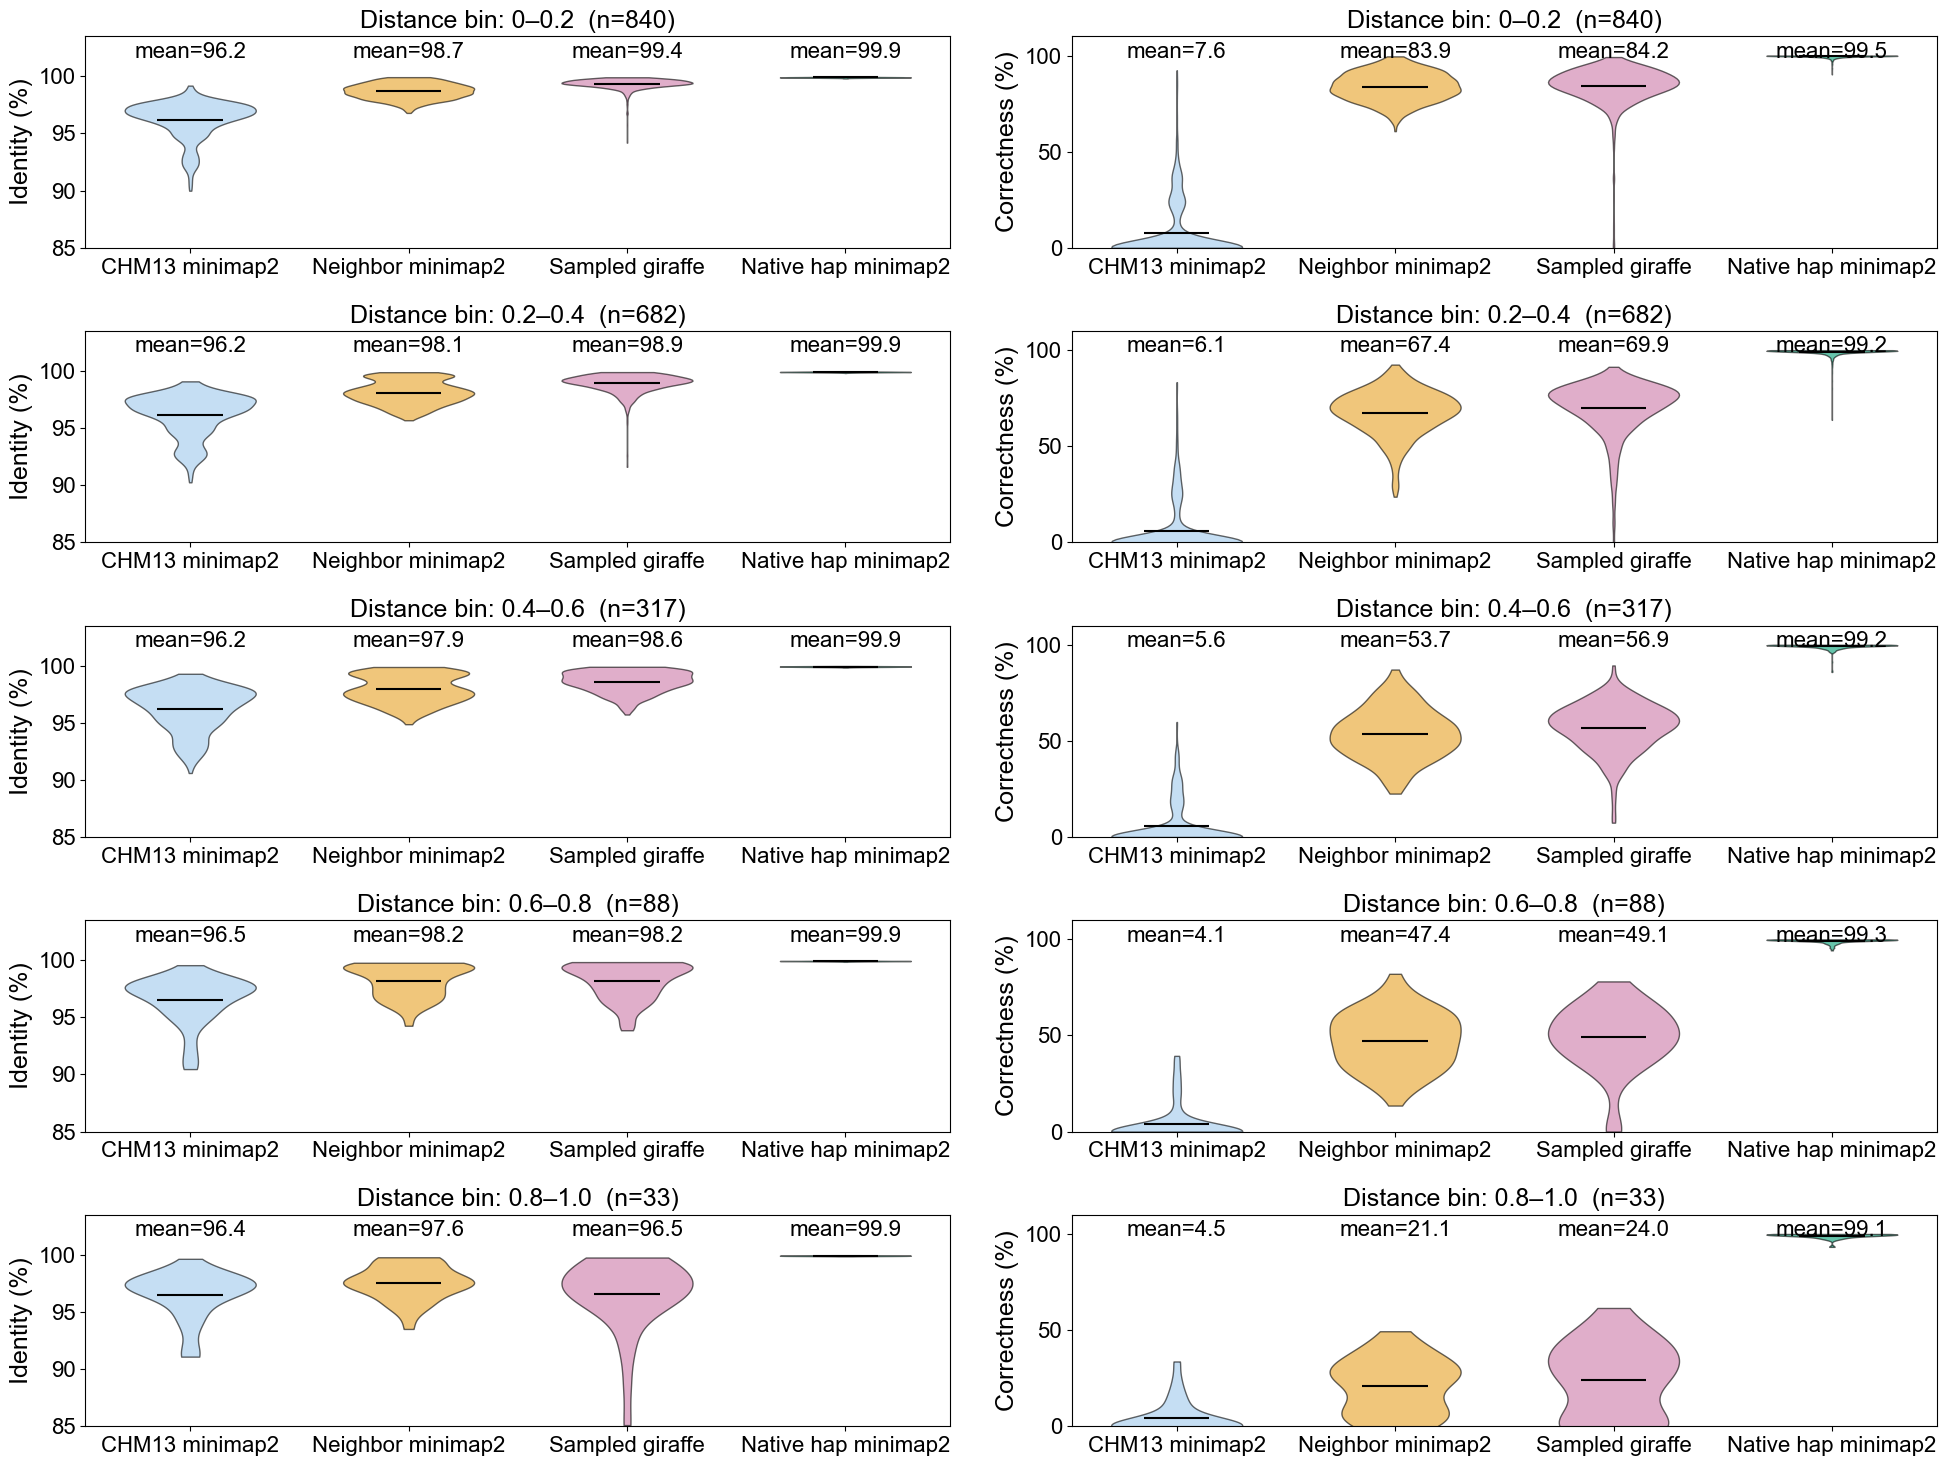

In [11]:
plt.rcParams.update({'font.size': 18, 'font.family': 'Arial'})

def violin_panel(ax, filt_df, cols, colors, ylabel, pW, pH, scale=1.0):
    for i, col in enumerate(cols):
        vals = pd.to_numeric(filt_df[col], errors='coerce').dropna().values * scale
        parts = ax.violinplot([vals], positions=[i], widths=0.6,
                              showmeans=True, showextrema=False)
        for pc in parts['bodies']:
            pc.set_facecolor(colors[i])
            pc.set_edgecolor('black')
            pc.set_alpha(0.6)
        parts['cmeans'].set_color('black')
        parts['cmeans'].set_linewidth(1.5)

        mean_val = np.mean(vals)
        ax.annotate(f'mean={mean_val:.1f}',
                    xy=(i, 0.88), xycoords=('data', 'axes fraction'),
                    ha='center', va='bottom', fontsize=16, clip_on=False)

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([' '.join(c.split()[:-2]) for c in cols], fontsize=16)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(axis='y', labelsize=16)


bins      = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]
bin_labels = ['0–0.2', '0.2–0.4', '0.4–0.6', '0.6–0.8', '0.8–1.0']

pW, pH = 10, 3
fig, axs = plt.subplots(len(bins), 2, figsize=(pW * 2, pH * len(bins)))

for row, ((lo, hi), label) in enumerate(zip(bins, bin_labels)):
    subset = filt_df[(filt_df['Minimum graph distance'] >= lo) &
                     (filt_df['Minimum graph distance'] <  hi)]

    ax_id  = axs[row, 0]
    ax_cor = axs[row, 1]

    if len(subset) == 0:
        ax_id.set_visible(False)
        ax_cor.set_visible(False)
        continue

    violin_panel(ax_id,  subset, id_cols,  colors, "Identity (%)",    pW, pH, scale=100)
    violin_panel(ax_cor, subset, cor_cols, colors, "Correctness (%)", pW, pH)

    ax_id.set_title(f"Distance bin: {label}  (n={len(subset)})", fontsize=18)
    ax_cor.set_title(f"Distance bin: {label}  (n={len(subset)})", fontsize=18)
    ax_id.set_ylim(85, 103.5)
    ax_cor.set_ylim(0, 110)

    from matplotlib.ticker import FormatStrFormatter
    ax_id.yaxis.set_major_formatter(FormatStrFormatter('%d'))

fig.tight_layout()
plt.show()


### P4. Per chrom stratified read alignment performance plots 

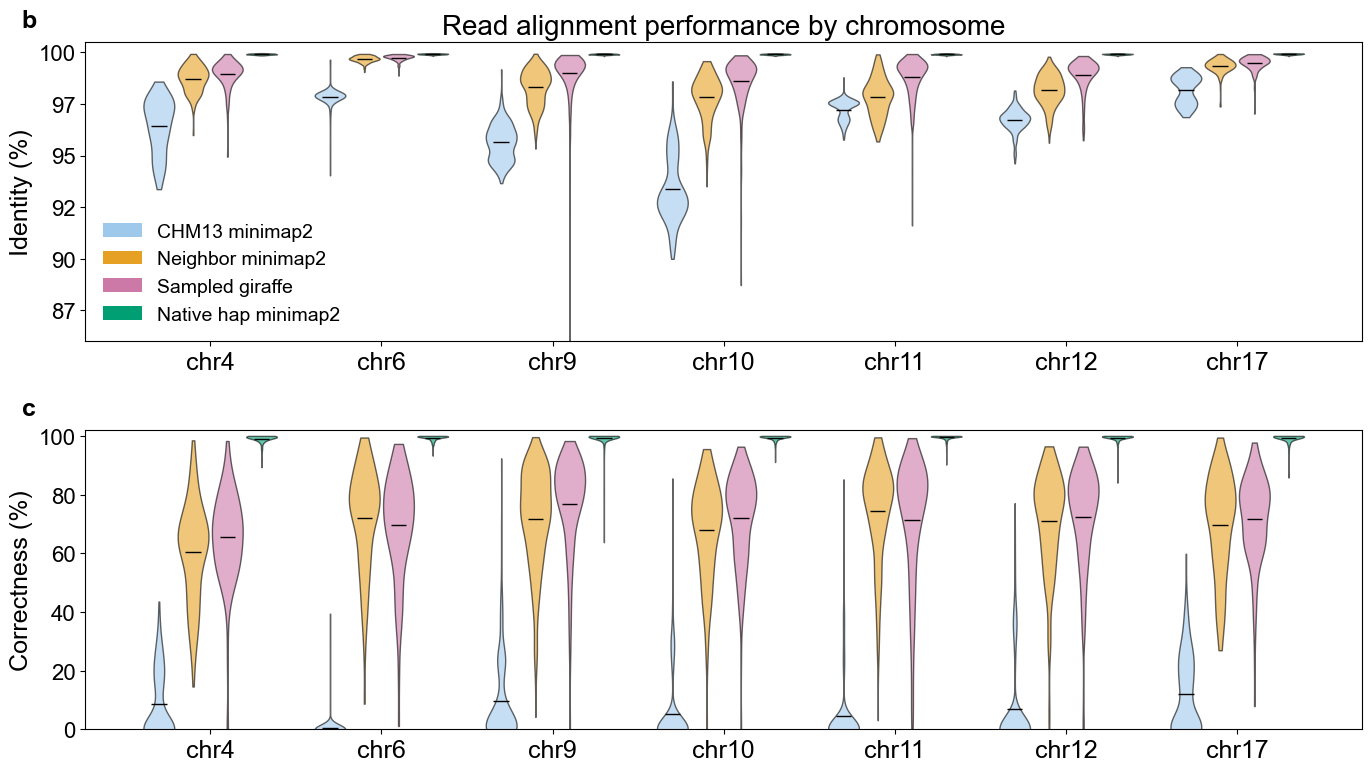

In [12]:
from matplotlib.ticker import FormatStrFormatter
plt.rcParams.update({'font.size': 16, 'font.family': 'Arial'})


def grouped_violin_panel(ax, filt_df, cols, colors, ylabel, scale=1.0):
    chrom_list = sorted(filt_df['Chromosome'].unique(),
                        key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 99)

    n         = len(cols)
    width     = 0.8
    offsets   = np.linspace(-width / 2 + width / (2 * n), width / 2 - width / (2 * n), n)
    vw        = width / n

    for i, chrom in enumerate(chrom_list):
        subset = filt_df[filt_df['Chromosome'] == chrom]
        for j, col in enumerate(cols):
            vals = pd.to_numeric(subset[col], errors='coerce').dropna().values * scale
            if len(vals) == 0:
                continue
            pos   = i + offsets[j]
            parts = ax.violinplot([vals], positions=[pos], widths=vw * 0.9,
                                  showmeans=True, showextrema=False)
            for pc in parts['bodies']:
                pc.set_facecolor(colors[j])
                pc.set_edgecolor('black')
                pc.set_alpha(0.6)
            parts['cmeans'].set_color('black')
            parts['cmeans'].set_linewidth(1.0)

    ax.set_xticks(range(len(chrom_list)))
    ax.set_xticklabels(chrom_list, fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.tick_params(axis='y', labelsize=16)

    # legend
    handles = [plt.matplotlib.patches.Patch(facecolor=colors[j], label=' '.join(c.split()[:-2]))
               for j, c in enumerate(cols)]
    ax.legend(handles=handles, fontsize=14, frameon=False)

pW, pH = 14, 4
fig, (ax_b, ax_c) = plt.subplots(2, 1, figsize=(pW, pH * 2))
ax_b.set_ylim(86, 100.5)
ax_c.set_ylim(0, 102)

grouped_violin_panel(ax_b, filt_df, id_cols,  colors, "Identity (%)",    scale=100)
grouped_violin_panel(ax_c, filt_df, cor_cols, colors, "Correctness (%)", scale=1)
ax_c.get_legend().remove()

ax_b.yaxis.set_major_formatter(FormatStrFormatter('%d'))
ax_b.set_title("Read alignment performance by chromosome", fontsize=20)

for ax, letter in zip([ax_b, ax_c], "bc"):
    ax.text(-0.05, 1.05, letter, transform=ax.transAxes, fontsize=18, fontweight="bold")

fig.tight_layout()
plt.show()



### Visualizing typing confidence with scores

Score Margin = difference in score between top two guessed haplotypes

In [17]:
### Read in cenhap assignments 

import os
import pandas as pd

base_dir = '/private/groups/migalab/juklucas/centrolign/cenhap_assignment/cenhap_inference_out'

dfs = []
for chrom in os.listdir(base_dir):
    fpath = os.path.join(base_dir, chrom, f'{chrom}.cenhap_predictions.tsv')
    if os.path.isfile(fpath):
        tmp = pd.read_csv(fpath, sep='\t', names=['sample', 'cenhap'], header=0)
        tmp['chrom'] = chrom
        dfs.append(tmp)

cenhap_labels_df = pd.concat(dfs, ignore_index=True)[['chrom', 'sample', 'cenhap']]
print(cenhap_labels_df.shape)
cenhap_labels_df.head()


(3248, 3)


,chrom,sample,cenhap
0,chr11,GRCh38.0,10
1,chr11,HG00097.1,3
2,chr11,HG00097.2,3
3,chr11,HG00099.1,2
4,chr11,HG00099.2,6


In [18]:
def score_diff_next_best(row, cenhap_lookup):
    chrom          = row['Chromosome']
    guessed_cenhap = row['Guessed cenhap']

    names  = [s.strip() for s in str(row['Sampled haplotype names']).split(',')]
    scores = [float(s.strip()) for s in str(row['Sampled haplotype scores']).split(',')]

    if not names or not scores:
        return 0

    paired    = sorted(zip(scores, names), reverse=True)
    top_score = paired[0][0]

    # first try: margin over next best with a different cenhap
    for score, name in paired:
        cenhap = cenhap_lookup.get((chrom, name), None)
        if cenhap is None:
            continue
        if cenhap != guessed_cenhap:
            return top_score - score

    # all guesses same cenhap: use top score itself as confidence
    return top_score


# build lookup dict from cenhap_labels_df
cenhap_lookup = {(row['chrom'], row['sample']): row['cenhap']
                 for _, row in cenhap_labels_df.iterrows()}

df['score_diff_next_diff_cenhap'] = df.apply(
    lambda row: score_diff_next_best(row, cenhap_lookup), axis=1
)

print(df['score_diff_next_diff_cenhap'].describe())
df[['Chromosome', 'Haplotype name', 'Guessed cenhap', 'score_diff_next_diff_cenhap']].head(10)


count    1960.000000
mean     2870.220503
std      2050.366547
min     -6508.700000
25%       718.525000
50%      2998.200000
75%      4786.975000
max      6932.200000
Name: score_diff_next_diff_cenhap, dtype: float64


,Chromosome,Haplotype name,Guessed cenhap,score_diff_next_diff_cenhap
0,chr11,HG00097.1,3.0,447.13
1,chr11,HG00097.2,3.0,5306.15
2,chr11,HG00099.1,2.0,1215.28
3,chr11,HG00126.1,2.0,1242.46
4,chr11,HG00126.2,3.0,5788.20
5,chr11,HG00128.1,3.0,5629.35
6,chr11,HG00128.2,3.0,5506.70
7,chr11,HG00133.1,3.0,5473.35
8,chr11,HG00133.2,5.0,5741.15
9,chr11,HG00140.1,5.0,5743.85


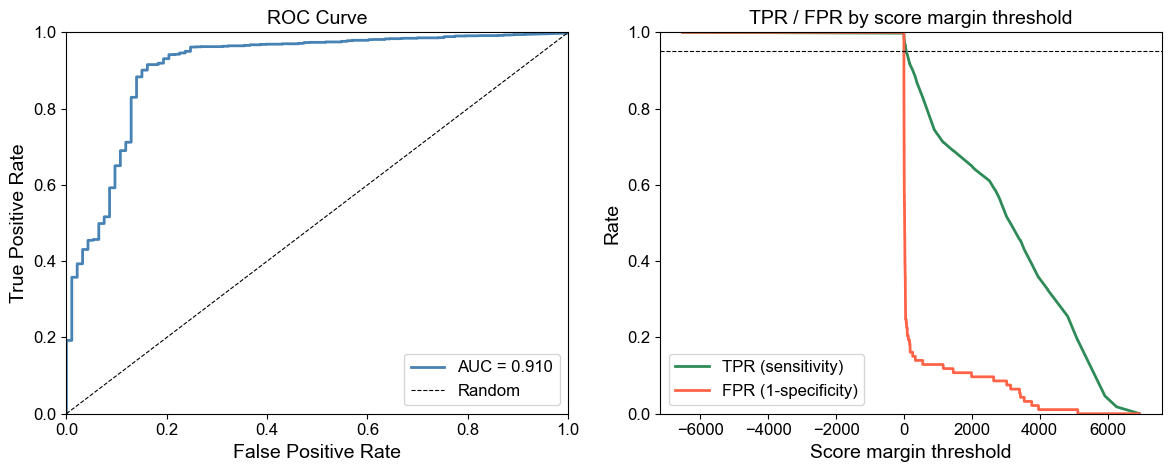

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

roc_df = df.dropna(subset=['score_diff_next_diff_cenhap']).copy()
roc_df['label'] = (roc_df['Truth cenhap'] == roc_df['Guessed cenhap']).astype(int)

fpr, tpr, thresholds = roc_curve(roc_df['label'], roc_df['score_diff_next_diff_cenhap'])
auc = roc_auc_score(roc_df['label'], roc_df['score_diff_next_diff_cenhap'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: ROC curve
ax1.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
ax1.plot([0, 1], [0, 1], color='black', linewidth=0.8, linestyle='--', label='Random')
ax1.set_xlabel("False Positive Rate", fontsize=14)
ax1.set_ylabel("True Positive Rate", fontsize=14)
ax1.set_title("ROC Curve", fontsize=14)
ax1.tick_params(labelsize=12)
ax1.legend(fontsize=12)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Panel 2: score margin threshold vs TPR/FPR
n = len(thresholds)
ax2.plot(thresholds, tpr[:n], color='seagreen', linewidth=2, label='TPR (sensitivity)')
ax2.plot(thresholds, fpr[:n], color='tomato',   linewidth=2, label='FPR (1-specificity)')

ax2.set_xlabel("Score margin threshold", fontsize=14)
ax2.set_ylabel("Rate", fontsize=14)
ax2.set_title("TPR / FPR by score margin threshold", fontsize=14)
ax2.tick_params(labelsize=12)
ax2.legend(fontsize=12)
ax2.set_ylim(0, 1)
ax2.axhline(0.95, color='black', linewidth=0.8, linestyle='--', label='TPR=0.95')

fig.tight_layout()
plt.show()


fig.tight_layout()
plt.show()



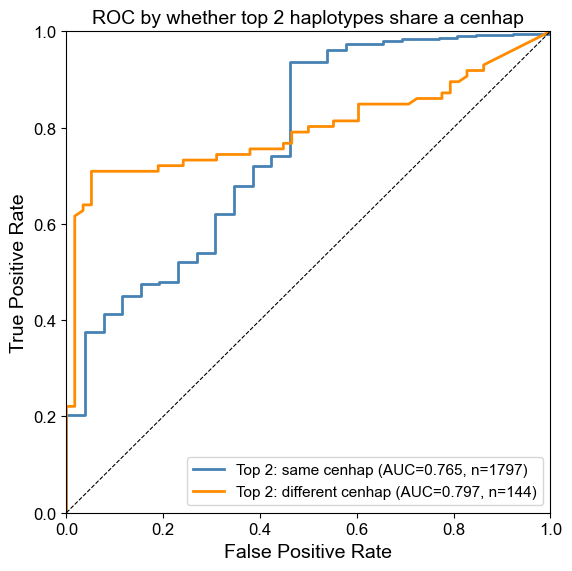

top_two_same_cenhap
True     1797
False     144
Name: count, dtype: int64


In [20]:
def top_two_same_cenhap(row, cenhap_lookup):
    chrom  = row['Chromosome']
    names  = [s.strip() for s in str(row['Sampled haplotype names']).split(',')]
    scores = [float(s.strip()) for s in str(row['Sampled haplotype scores']).split(',')]
    if len(names) < 2:
        return None
    paired = sorted(zip(scores, names), reverse=True)
    c1 = cenhap_lookup.get((chrom, paired[0][1]), None)
    c2 = cenhap_lookup.get((chrom, paired[1][1]), None)
    if c1 is None or c2 is None:
        return None
    return c1 == c2

df['top_two_same_cenhap'] = df.apply(lambda r: top_two_same_cenhap(r, cenhap_lookup), axis=1)

# ── plot two ROC curves ───────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 6))

for same, label, color in [(True, 'Top 2: same cenhap', 'steelblue'),
                            (False, 'Top 2: different cenhap', 'darkorange')]:
    subset = df[df['top_two_same_cenhap'] == same].copy()
    subset['label'] = (subset['Truth cenhap'] == subset['Guessed cenhap']).astype(int)
    fpr_, tpr_, _ = roc_curve(subset['label'], subset['score_diff_next_diff_cenhap'])
    auc_ = roc_auc_score(subset['label'], subset['score_diff_next_diff_cenhap'])
    ax.plot(fpr_, tpr_, color=color, linewidth=2, label=f'{label} (AUC={auc_:.3f}, n={len(subset)})')

ax.plot([0, 1], [0, 1], color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("False Positive Rate", fontsize=14)
ax.set_ylabel("True Positive Rate", fontsize=14)
ax.set_title("ROC by whether top 2 haplotypes share a cenhap", fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

fig.tight_layout()
plt.show()

print(df['top_two_same_cenhap'].value_counts())


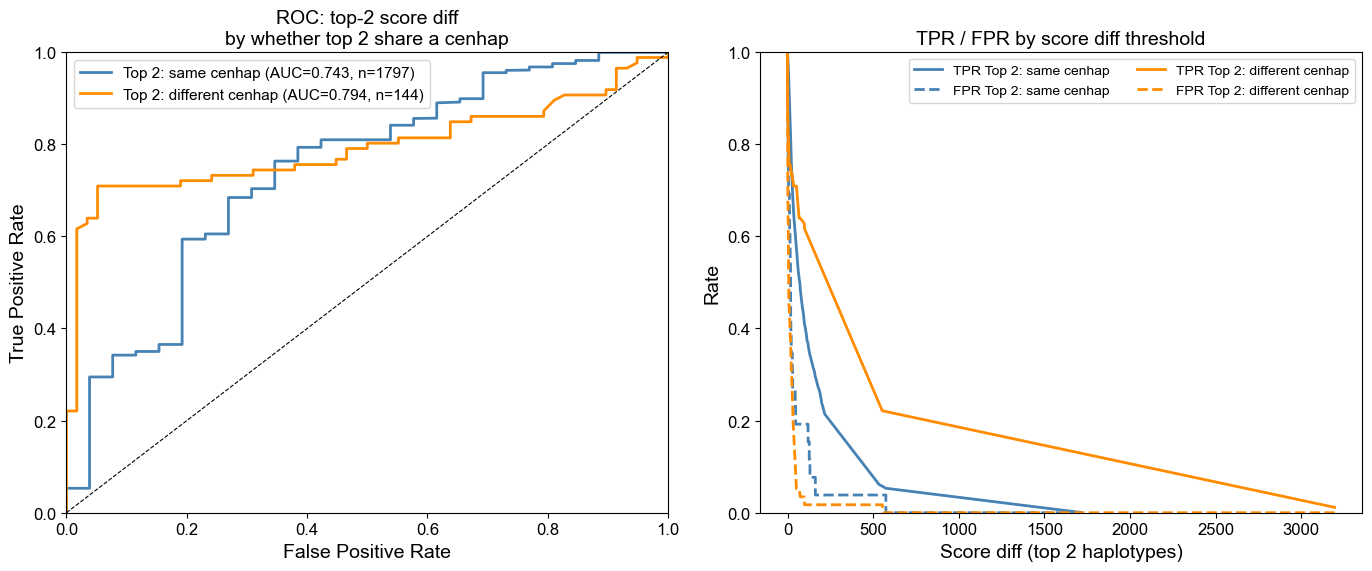

count    1960.000000
mean      159.848535
std       258.696343
min         0.000000
25%        21.700000
50%        65.550000
75%       194.450000
max      3194.900000
Name: score_diff_top_two, dtype: float64


In [21]:
def score_diff_top_two(row):
    names  = [s.strip() for s in str(row['Sampled haplotype names']).split(',')]
    scores = [float(s.strip()) for s in str(row['Sampled haplotype scores']).split(',')]

    if len(scores) < 2:
        return 0

    paired = sorted(zip(scores, names), reverse=True)
    return paired[0][0] - paired[1][0]

df['score_diff_top_two'] = df.apply(score_diff_top_two, axis=1)

# ── ROC split by whether top 2 share a cenhap ────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for same, label, color in [(True,  'Top 2: same cenhap',      'steelblue'),
                            (False, 'Top 2: different cenhap', 'darkorange')]:
    subset = df[df['top_two_same_cenhap'] == same].copy()
    subset['label'] = (subset['Truth cenhap'] == subset['Guessed cenhap']).astype(int)

    fpr_, tpr_, thresh_ = roc_curve(subset['label'], subset['score_diff_top_two'])
    auc_ = roc_auc_score(subset['label'], subset['score_diff_top_two'])

    ax1.plot(fpr_, tpr_, color=color, linewidth=2,
             label=f'{label} (AUC={auc_:.3f}, n={len(subset)})')

    n = len(thresh_)
    ax2.plot(thresh_, tpr_[:n], color=color,   linewidth=2, linestyle='-',  label=f'TPR {label}')
    ax2.plot(thresh_, fpr_[:n], color=color,   linewidth=2, linestyle='--', label=f'FPR {label}')

ax1.plot([0, 1], [0, 1], color='black', linewidth=0.8, linestyle='--')
ax1.set_xlabel("False Positive Rate", fontsize=14)
ax1.set_ylabel("True Positive Rate", fontsize=14)
ax1.set_title("ROC: top-2 score diff\nby whether top 2 share a cenhap", fontsize=14)
ax1.tick_params(labelsize=12)
ax1.legend(fontsize=11)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

ax2.set_xlabel("Score diff (top 2 haplotypes)", fontsize=14)
ax2.set_ylabel("Rate", fontsize=14)
ax2.set_title("TPR / FPR by score diff threshold", fontsize=14)
ax2.tick_params(labelsize=12)
ax2.legend(fontsize=10, ncol=2)
ax2.set_ylim(0, 1)

fig.tight_layout()
plt.show()

print(df['score_diff_top_two'].describe())


In [16]:
fpr_c, tpr_c, _ = roc_curve(y, -combined_score)


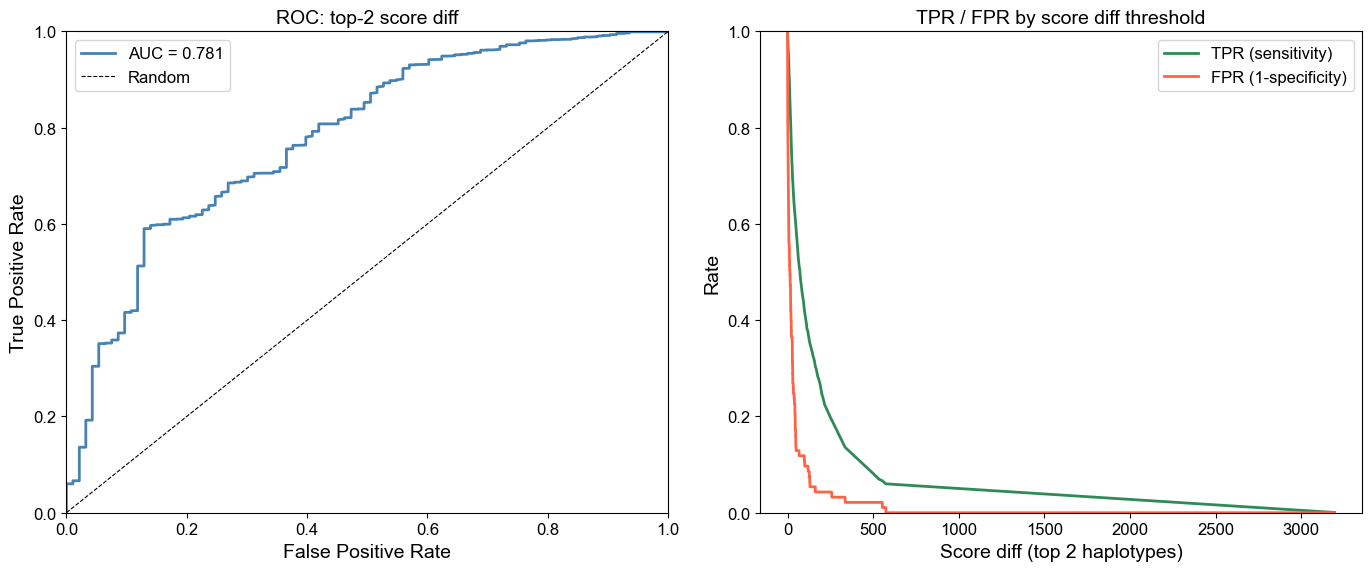

In [22]:
roc_df = df.copy()
roc_df['label'] = (roc_df['Truth cenhap'] == roc_df['Guessed cenhap']).astype(int)

fpr, tpr, thresholds = roc_curve(roc_df['label'], roc_df['score_diff_top_two'])
auc = roc_auc_score(roc_df['label'], roc_df['score_diff_top_two'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {auc:.3f}')
ax1.plot([0, 1], [0, 1], color='black', linewidth=0.8, linestyle='--', label='Random')
ax1.set_xlabel("False Positive Rate", fontsize=14)
ax1.set_ylabel("True Positive Rate", fontsize=14)
ax1.set_title("ROC: top-2 score diff", fontsize=14)
ax1.tick_params(labelsize=12)
ax1.legend(fontsize=12)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

n = len(thresholds)
ax2.plot(thresholds, tpr[:n], color='seagreen', linewidth=2, label='TPR (sensitivity)')
ax2.plot(thresholds, fpr[:n], color='tomato',   linewidth=2, label='FPR (1-specificity)')
ax2.set_xlabel("Score diff (top 2 haplotypes)", fontsize=14)
ax2.set_ylabel("Rate", fontsize=14)
ax2.set_title("TPR / FPR by score diff threshold", fontsize=14)
ax2.tick_params(labelsize=12)
ax2.legend(fontsize=12)
ax2.set_ylim(0, 1)

fig.tight_layout()
plt.show()


## RGFA figure data wrangling

In [ ]:
import pandas as pd
import re
import json
import csv

df_csv = pd.read_csv(
    '/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/MSA/centrolign_results.csv',
    header=0
)

# filter to release 2 QC v2 rows
df_csv.columns = df_csv.columns.str.strip()
filt_csv = df_csv[df_csv.iloc[:, 1].str.strip() == 'release 2 QC v2']

# extract chromosome from first column (e.g. chr5_subgroup0 -> chr5)
def extract_chrom(val):
    match = re.match(r'(chr[\w]+?)(?:_subgroup.*)?$', str(val).strip())
    return match.group(1) if match else val

filt_csv = filt_csv.copy()
filt_csv['chrom'] = filt_csv.iloc[:, 0].apply(extract_chrom)

# group GFA paths by chromosome
gfa_col = df_csv.columns[8]  # 'gfa'
gfa_by_chrom = (filt_csv.groupby('chrom')[gfa_col]
                .apply(lambda x: list(x.dropna().str.strip()))
                .to_dict())

def chrom_sort_key(chrom):
    match = re.match(r'chr(\d+|x|y|m)$', chrom.lower())
    if match:
        token = match.group(1)
        if token.isdigit():
            return (0, int(token))
        return (0, {'x': 23, 'y': 24, 'm': 25}.get(token, 99))
    return (1, chrom)

with open('/private/groups/patenlab/mira/gfas.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow([chrom, json.dumps(gfas, separators=(',', ':'))])
    for chrom, gfas in sorted(gfa_by_chrom.items(), key=lambda x: chrom_sort_key(x[0])):
        writer.writerow([chrom, json.dumps(gfas, separators=(',', ':'))])

print("Written to /private/groups/patenlab/mira/gfas.csv")

Written to /private/groups/patenlab/mira/gfas.csv
